<a href="https://colab.research.google.com/github/himanshu-sheetlani/ML-Course/blob/main/Logistic_Spam_Ham_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 2. Load dataset
dataset = pd.read_csv(
    "/spamhamdata.csv",
    sep='\t',
    names=['label', 'text'],
    encoding='latin-1'
)

print(dataset.head())

print(dataset.head())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
# Assuming columns: label, text
X = dataset.iloc[:, 1].values   # text
y = dataset.iloc[:, 0].values   # label

# Convert labels to 0/1
y = np.where(y == 'spam', 1, 0)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print(X_train[:5])
print(X_test[:5])
print(y_train[:5])
print(y_test[:5])

['Its going good...no problem..but still need little experience to understand american customer voice...'
 'U have a secret admirer. REVEAL who thinks U R So special. Call 09065174042. To opt out Reply REVEAL STOP. 1.50 per msg recd. Cust care 07821230901'
 'Ok...'
 "Huh... Hyde park not in mel ah, opps, got confused... Anyway, if tt's e best choice den we juz have to take it..."
 'Just hopeing that wasnâ\x80\x98t too pissed up to remember and has gone off to his sisters or something!']
['Storming msg: Wen u lift d phne, u say "HELLO" Do u knw wt is d real meaning of HELLO?? . . . It\'s d name of a girl..! . . . Yes.. And u knw who is dat girl?? "Margaret Hello" She is d girlfrnd f Grahmbell who invnted telphone... . . . . Moral:One can 4get d name of a person, bt not his girlfrnd... G o o d n i g h t . . .@'
 '<Forwarded from 448712404000>Please CALL 08712404000 immediately as there is an urgent message waiting for you.'
 "And also I've sorta blown him off a couple times recently so i

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

sc = TfidfVectorizer(stop_words='english')

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(4179, 7317)
(1393, 7317)


In [6]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [7]:
# Test single example
print(classifier.predict(sc.transform(["Win a free lottery now!!!"])))

[1]


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9662598707824839
[[1207    1]
 [  46  139]]


/tmp/ipykernel_1766/3780198055.py:33: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


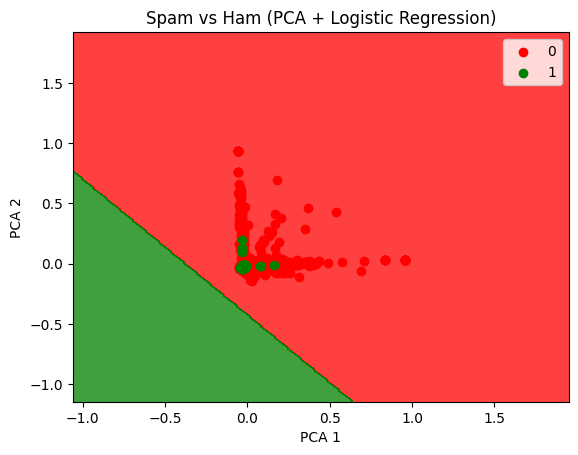

In [9]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# Convert sparse → dense
X_vis = X_train.toarray()

# Reduce to 2D
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_vis)

y_vis = y_train

# Train model again on reduced data
classifier_vis = LogisticRegression()
classifier_vis.fit(X_vis, y_vis)

# Create mesh grid (same as your code)
X1, X2 = np.meshgrid(
    np.arange(X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1, 0.01),
    np.arange(X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1, 0.01)
)

# Plot decision boundary
plt.contourf(
    X1, X2,
    classifier_vis.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

# Plot points
for i, j in enumerate(np.unique(y_vis)):
    plt.scatter(
        X_vis[y_vis == j, 0],
        X_vis[y_vis == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title("Spam vs Ham (PCA + Logistic Regression)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()